In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"text.usetex": True})
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.fallback'] = 'stix'
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('seaborn-v0_8-deep')
prop_cycle = plt.rcParams['axes.prop_cycle']
dcolors = prop_cycle.by_key()['color']

In [2]:
import re

L = 64
bc = "PBC"
t = 1.0
g = 0.856
parity = 1
maxdim = 400

fname = f"L{L}_{bc}_t{t}_g{g}_parity{parity}_maxdim{maxdim}.csv"
df = pd.read_csv(fname)

print(f"Loaded: {fname}")

def parse_julia_array(julia_str):
    if not isinstance(julia_str, str):
        return np.array(julia_str)
    julia_str = re.sub(r'ComplexF64\[', '[', julia_str)
    julia_str = re.sub(r'(\d+)im', r'\1j', julia_str)
    return np.array(eval(julia_str))

def unflatten_correlation(flat_vec_str, L):
    flat_vec = parse_julia_array(flat_vec_str)
    return np.real(flat_vec.reshape(L, L))

XXC_1 = unflatten_correlation(df["XXC"].iloc[0], L)
XXC_2 = unflatten_correlation(df["XXC"].iloc[1], L)
XXCC_1 = unflatten_correlation(df["XXCC"].iloc[0], L)
XXCC_2 = unflatten_correlation(df["XXCC"].iloc[1], L)

YYC_1 = unflatten_correlation(df["YYC"].iloc[0], L)
YYC_2 = unflatten_correlation(df["YYC"].iloc[1], L)
YYCC_1 = unflatten_correlation(df["YYCC"].iloc[0], L)
YYCC_2 = unflatten_correlation(df["YYCC"].iloc[1], L)

ZZC_1 = unflatten_correlation(df["ZZC"].iloc[0], L)
ZZC_2 = unflatten_correlation(df["ZZC"].iloc[1], L)
ZZCC_1 = unflatten_correlation(df["ZZCC"].iloc[0], L)
ZZCC_2 = unflatten_correlation(df["ZZCC"].iloc[1], L)

E1 = df["energy"].iloc[0]
E2 = df["energy"].iloc[1]
gap = df["gap"].iloc[0]

print(f"\nEnergy 1 = {E1:.6f}")
print(f"Energy 2 = {E2:.6f}")
print(f"Gap = {gap:.6f}")

Loaded: L64_PBC_t1.0_g0.856_parity1_maxdim400.csv

Energy 1 = -129.536054
Energy 2 = -129.472133
Gap = 0.063921


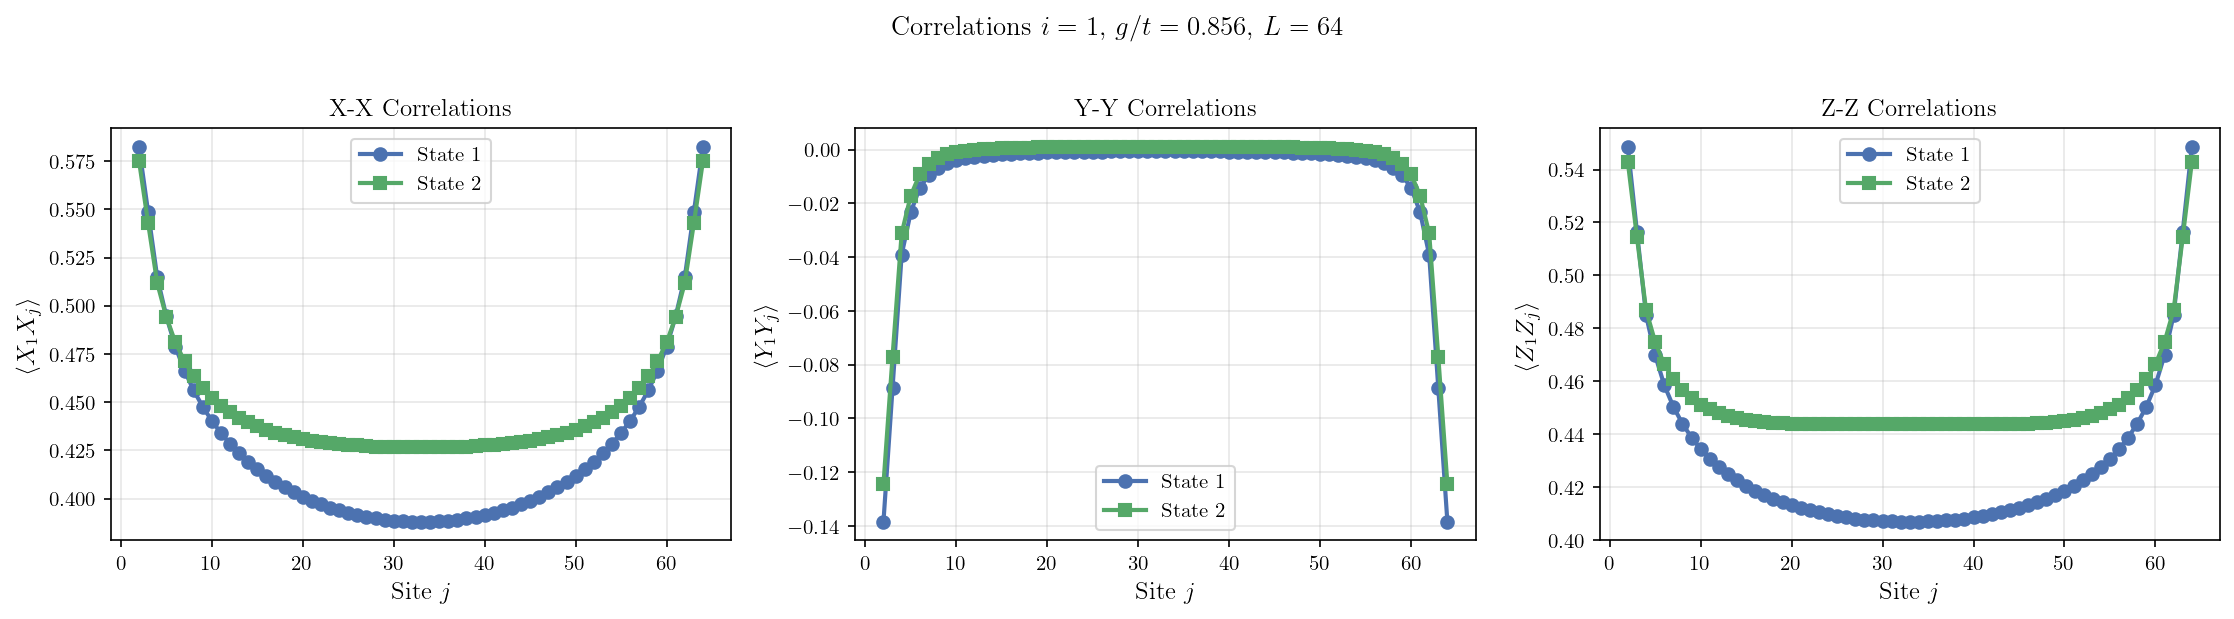

In [3]:
# Correlations

i_ref = 0
site_label = i_ref + 1
j_sites = np.arange(1, L+1)
mask = j_sites != site_label
j_plot = j_sites[mask]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

operators = [('X', XXC_1, XXC_2), ('Y', YYC_1, YYC_2), ('Z', ZZC_1, ZZC_2)]
for ax, (op, corr1, corr2) in zip(axes, operators):
    ax.plot(j_plot, corr1[i_ref, mask], 'o-', label="State 1", color=dcolors[0], linewidth=2)
    ax.plot(j_plot, corr2[i_ref, mask], 's-', label="State 2", color=dcolors[1], linewidth=2)
    ax.set_xlabel(r"Site $j$", fontsize=12)
    ax.set_ylabel(rf"$\langle {op}_{{{site_label}}} {op}_j \rangle$", fontsize=12)
    ax.set_title(f"{op}-{op} Correlations", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.suptitle(f"Correlations $i={site_label}$, $g/t={g}$, $L={L}$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]


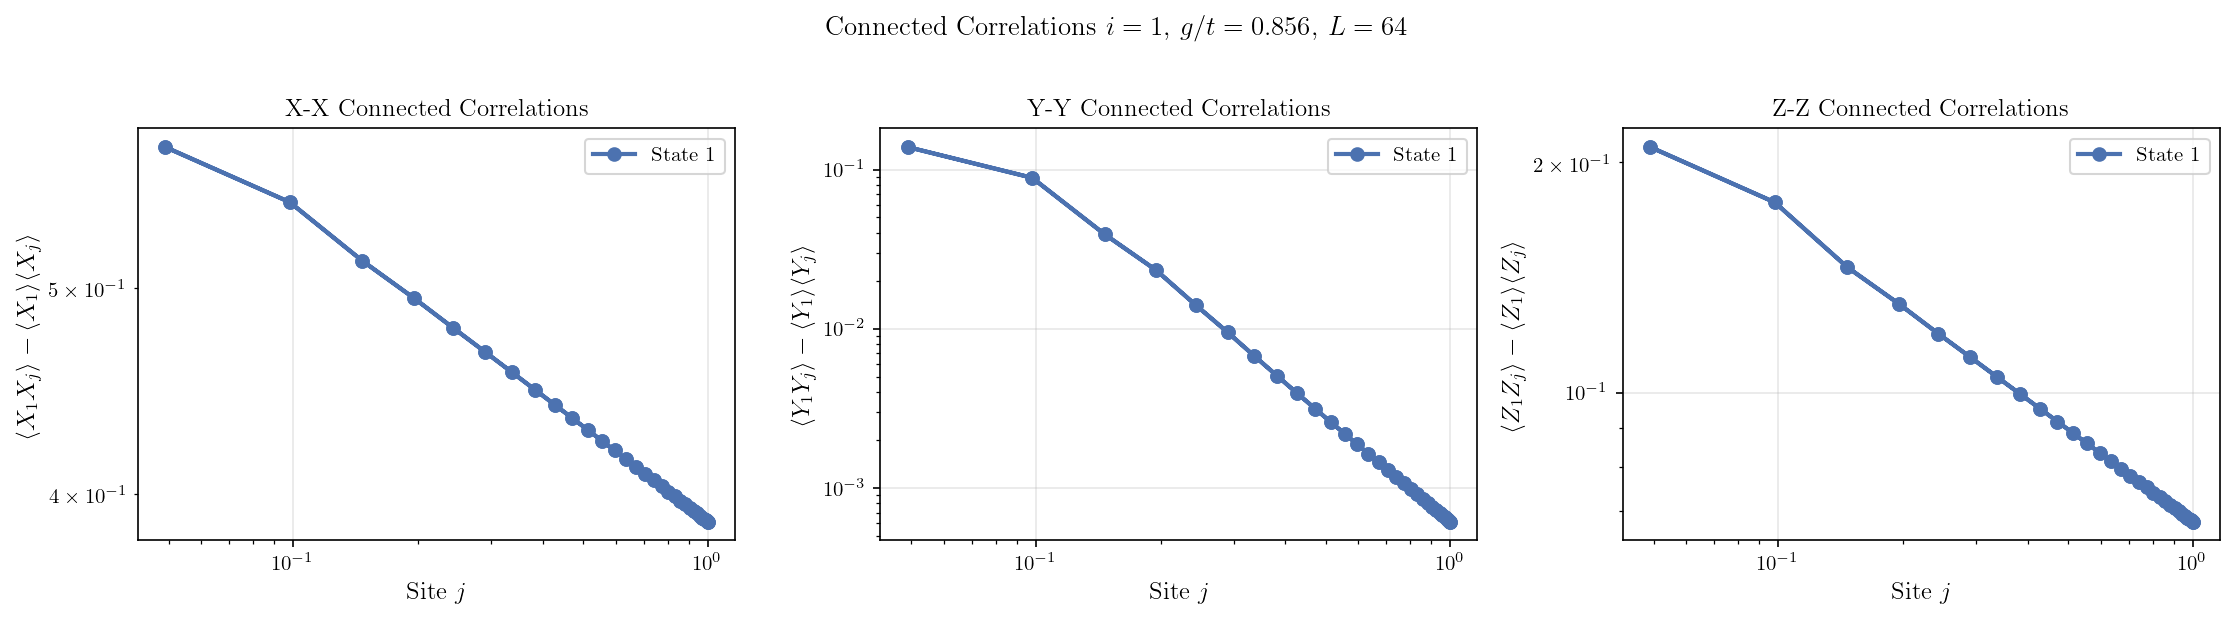

In [4]:
# Connected Correlations

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

operators = [('X', XXCC_1, XXCC_2), ('Y', YYCC_1, YYCC_2), ('Z', ZZCC_1, ZZCC_2)]
for ax, (op, corr1, corr2) in zip(axes, operators):
    ax.plot(np.sin((j_plot-1)*np.pi/L), np.abs(corr1[i_ref, mask]), 'o-', label="State 1", color=dcolors[0], linewidth=2)
    # ax.plot(mp.sin(j_plot), corr2[i_ref, mask], 's-', label="State 2", color=dcolors[1], linewidth=2)
    ax.set_xlabel(r"Site $j$", fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(rf"$\langle {op}_{{{site_label}}} {op}_j \rangle - \langle {op}_{{{site_label}}} \rangle \langle {op}_j \rangle$", fontsize=12)
    ax.set_title(f"{op}-{op} Connected Correlations", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
print(j_plot)
plt.suptitle(f"Connected Correlations $i={site_label}$, $g/t={g}$, $L={L}$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

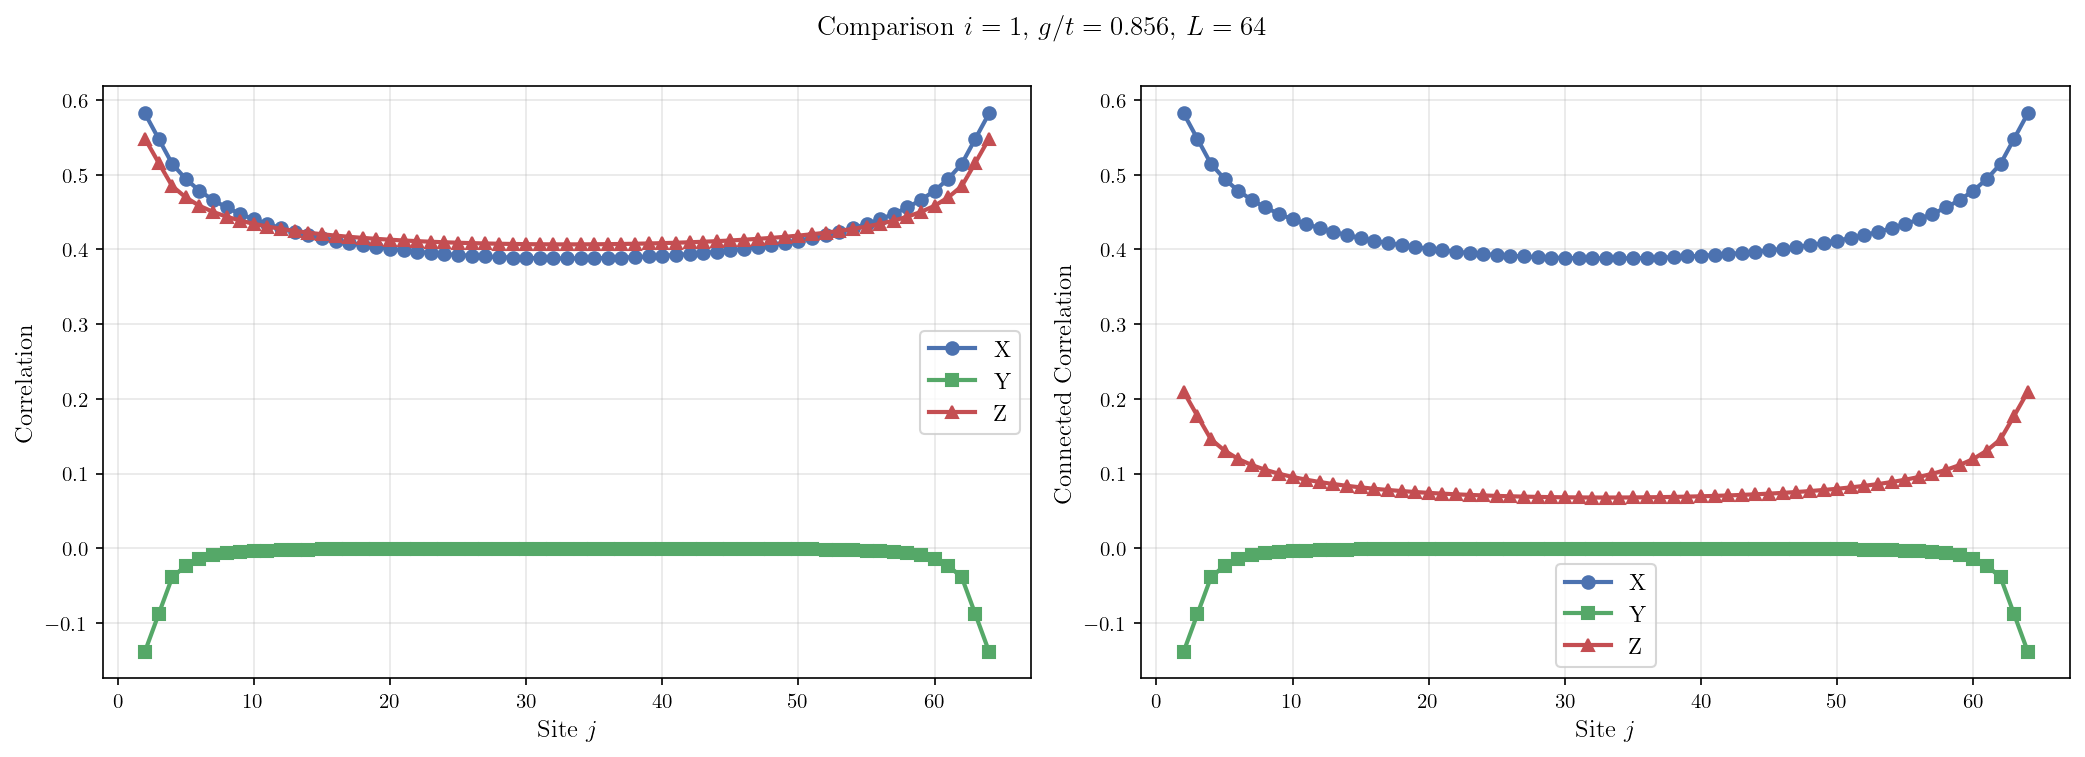

In [5]:
# Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

operators = ['X', 'Y', 'Z']
corr_raw = [XXC_1, YYC_1, ZZC_1]
corr_cc = [XXCC_1, YYCC_1, ZZCC_1]
markers = ['o-', 's-', '^-']

for op, corr, marker in zip(operators, corr_raw, markers):
    axes[0].plot(j_plot, corr[i_ref, mask], marker, label=op, color=dcolors[operators.index(op)], linewidth=2)

for op, corr, marker in zip(operators, corr_cc, markers):
    axes[1].plot(j_plot, corr[i_ref, mask], marker, label=op, color=dcolors[operators.index(op)], linewidth=2)

axes[0].set_xlabel(r"Site $j$", fontsize=12)
axes[0].set_ylabel(r"Correlation", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

axes[1].set_xlabel(r"Site $j$", fontsize=12)
axes[1].set_ylabel(r"Connected Correlation", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.suptitle(f"Comparison $i={site_label}$, $g/t={g}$, $L={L}$", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# run from g/t=0.5 to g/t=1.5 in 101 steps
# use linspace or arange
# L = 32 with OBC
# maxdim = 200
# approximately 4GB of RAM
# something like 8 threads